# EDA - Fraud Dataset

Análisis exploratorio del dataset `MercadoLibre Data Scientist Hiring Test - Fraud Dataset with date v2.csv`.

Puntos cubiertos:
1. Estructura general del dataset (filas, columnas, tipos de dato numéricos/categóricos)
2. Rango de fechas y columna asociada
3. Columnas candidatas a ser identificadores (IDs)
4. Distribución del target (`fraude`) mes a mes

# Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT_DIR = Path.cwd().parent if (Path.cwd().name == "01_EDA") else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from src.utils.eda import EDA
from src.utils.graphics_utils import plot_daily_amount_evolution, plot_economic_impact

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Configs

In [2]:

DATA_PATH = ROOT_DIR / "dataset" / "MercadoLibre Data Scientist Hiring Test - Fraud Dataset with date v2.csv"
OUTPUT_DIR = ROOT_DIR / "01_EDA"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
TARGET_COL = "fraude"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

PosixPath('/Users/dpiedrahita/proyectos/DS_pro/dataset/MercadoLibre Data Scientist Hiring Test - Fraud Dataset with date v2.csv')

# Read Data

In [3]:
eda = EDA(DATA_PATH)
df = eda.load()
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 19)


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


## 1. Estructura general del dataset

In [4]:
structure = eda.general_structure()

print(f"Filas: {structure['n_rows']:,}")
print(f"Columnas: {structure['n_cols']}")
print(f"Numéricas ({len(structure['numeric_cols'])}): {structure['numeric_cols']}")
print(f"Categóricas/texto ({len(structure['categorical_cols'])}): {structure['categorical_cols']}")
print(f"Fecha/datetime ({len(structure['datetime_cols'])}): {structure['datetime_cols']}")
print(f"Binarias ({len(structure['binary_cols'])}): {structure['binary_cols']}")

top_ceros = (
    structure["dtypes_summary"]
    .dropna(subset=["pct_ceros"])
    .sort_values("pct_ceros", ascending=False)
    .head(5)[["columna", "n_ceros", "pct_ceros"]]
)
print("\nColumnas numéricas con mayor % de ceros:")
print(top_ceros.to_string(index=False))

structure["dtypes_summary"].to_csv(TABLES_DIR / "01_estructura_general.csv", index=False)
structure["dtypes_summary"]

Filas: 150,000
Columnas: 19
Numéricas (14): ['a', 'b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'n', 'monto', 'score', 'fraude']
Categóricas/texto (4): ['g', 'j', 'o', 'p']
Fecha/datetime (1): ['fecha']
Binarias (4): ['n', 'o', 'p', 'fraude']

Columnas numéricas con mayor % de ceros:
columna  n_ceros  pct_ceros
 fraude 142500.0     0.9500
      e  65055.0     0.4337
      f  25390.0     0.1693
      m  15898.0     0.1060
      n  14647.0     0.0976


,columna,dtype,tipo_general,binaria,n_unicos,pct_unicos,n_nulos,pct_nulos,n_ceros,pct_ceros
0,a,int64,numérica,False,4,0.0000,0,0.0000,0.0,0.0000
1,b,float64,numérica,False,7672,0.0511,12984,0.0866,472.0,0.0031
2,c,float64,numérica,False,135090,0.9006,12984,0.0866,0.0,0.0000
3,d,float64,numérica,False,51,0.0003,365,0.0024,786.0,0.0052
4,e,float64,numérica,False,43208,0.2881,0,0.0000,65055.0,0.4337
5,f,float64,numérica,False,1338,0.0089,11,0.0001,25390.0,0.1693
6,g,str,categórica/texto,False,51,0.0003,194,0.0013,NaN,NaN
7,h,int64,numérica,False,59,0.0004,0,0.0000,12840.0,0.0856
8,j,str,categórica/texto,False,8324,0.0555,0,0.0000,NaN,NaN
9,k,float64,numérica,False,150000,1.0000,0,0.0000,0.0,0.0000


## 2. Rango de fechas

In [5]:
date_info = eda.date_range_summary()
print(f"Columna(s) de fecha detectada(s): {date_info['date_columns']}")

date_info["summary"].to_csv(TABLES_DIR / "02_rango_fechas.csv", index=False)
date_info["summary"]

Columna(s) de fecha detectada(s): ['fecha']


,columna,fecha_min,fecha_max,dias_cubiertos,n_registros
0,fecha,2020-03-08 00:02:15,2020-04-21 23:59:56,44,150000


## 3. Columnas candidatas a ID

In [6]:
id_cols = eda.id_like_columns()
id_cols.to_csv(TABLES_DIR / "03_columnas_id_candidatas.csv", index=False)
id_cols

,columna,n_unicos,pct_unicos,motivo
0,k,150000,1.0000,~100% de valores únicos (posible identificador...
1,c,135090,0.9006,~90% de valores únicos (posible identificador ...
2,j,8324,0.0555,patrón tipo prefijo_hash (posible identificado...


**Noctas adicionales:**
- `k` identificador de valór único, esta es la columna ID
- `c` y `b` tiene una cantidad modereada de nulos cerca a un 8%
- `j` no es único por fila, pero su patrón `cat_hash` sugiere que es un identificador de categoría/entidad (llave foránea) repetido entre registros.
- Las columnas de fecha se excluyen de este análisis (se tratan en la sección 2), ya que su alta cardinalidad es un artefacto de la granularidad del timestamp.

## 4. Distribución del target por periodo (`fraude`)

Se realiza la distribución de fraude durante el eprioro de tiempo determinado en el dataset, esto es importante confirmarlo y ver si hay dias o semanas que acumulen una mayor cantidad de fraude

### 4.1 Día a día

In [7]:
daily = eda.target_daily_distribution(TARGET_COL)
daily.to_csv(TABLES_DIR / "04a_distribucion_diaria_target.csv", index=False)
daily

,periodo,n_total,n_positivos,n_negativos,tasa_positivos
0,2020-03-08,2838,124,2714,0.0437
1,2020-03-09,4173,197,3976,0.0472
2,2020-03-10,4105,187,3918,0.0456
3,2020-03-11,3899,203,3696,0.0521
4,2020-03-12,3787,181,3606,0.0478
5,2020-03-13,3229,162,3067,0.0502
6,2020-03-14,2560,135,2425,0.0527
7,2020-03-15,2770,119,2651,0.0430
8,2020-03-16,4202,180,4022,0.0428
9,2020-03-17,4280,201,4079,0.0470


In [8]:
print(f"Cantidad total de fraude: -------> {daily["n_positivos"].sum()}")
print(f"Cantidad total de no fraude: ----> {daily["n_negativos"].sum()}")


Cantidad total de fraude: -------> 7500
Cantidad total de no fraude: ----> 142500


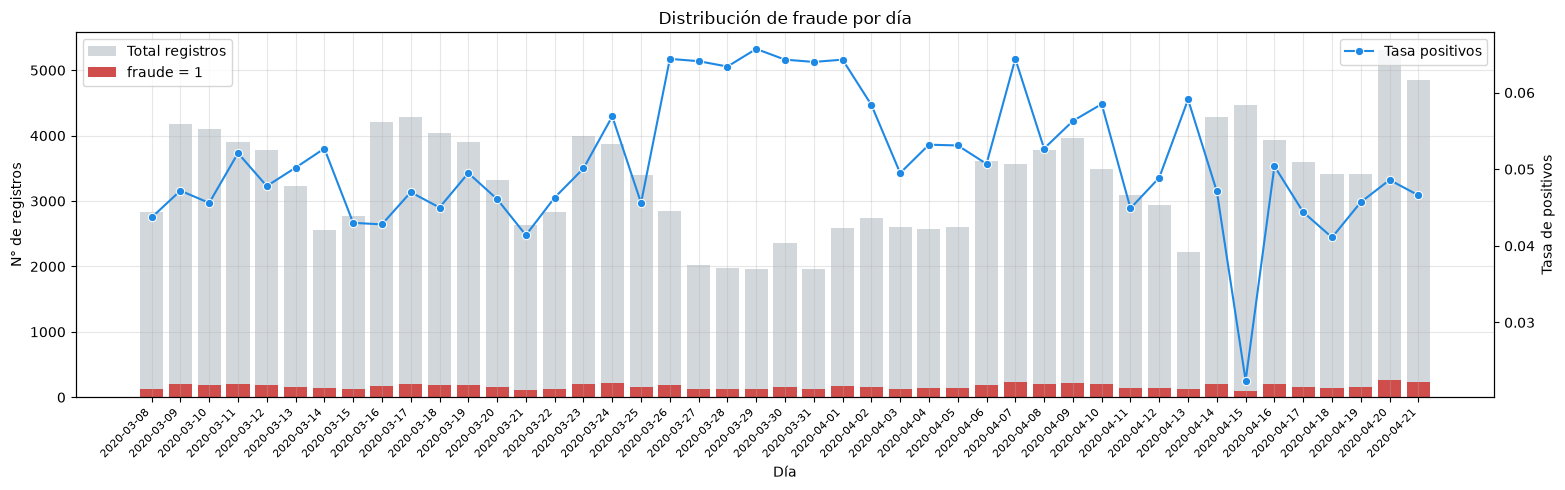

In [9]:
eda.plot_target_by_period(
    daily,
    output_path=FIGURES_DIR / "distribucion_diaria_target.png",
    target_name=TARGET_COL,
    freq="D",
    close=False,
)
plt.show()

**Notas adcionales**
- Se Puede observar en el grafico anterior, que la tasa de fraude en general varía entre un 0.03 y un 0.06
- Se peude observar que la tasa de fraude entre los días 26 de marzo al 1 de abril superaron el 0.06 de fraude, sin embargo, este periodo de tiempo obtuvo una menor cantidad de transacciones

### 4.2 Semana a semana

In [10]:
weekly = eda.target_weekly_distribution(TARGET_COL)
weekly.to_csv(TABLES_DIR / "04b_distribucion_semanal_target.csv", index=False)
weekly

,periodo,rango_fechas,n_total,n_positivos,n_negativos,tasa_positivos
0,semana_1,2020-03-02/2020-03-08,2838,124,2714,0.0437
1,semana_2,2020-03-09/2020-03-15,24523,1184,23339,0.0483
2,semana_3,2020-03-16/2020-03-22,25199,1149,24050,0.0456
3,semana_4,2020-03-23/2020-03-29,20069,1142,18927,0.0569
4,semana_5,2020-03-30/2020-04-05,17434,1008,16426,0.0578
5,semana_6,2020-04-06/2020-04-12,24443,1322,23121,0.0541
6,semana_7,2020-04-13/2020-04-19,25332,1087,24245,0.0429
7,semana_8,2020-04-20/2020-04-26,10162,484,9678,0.0476


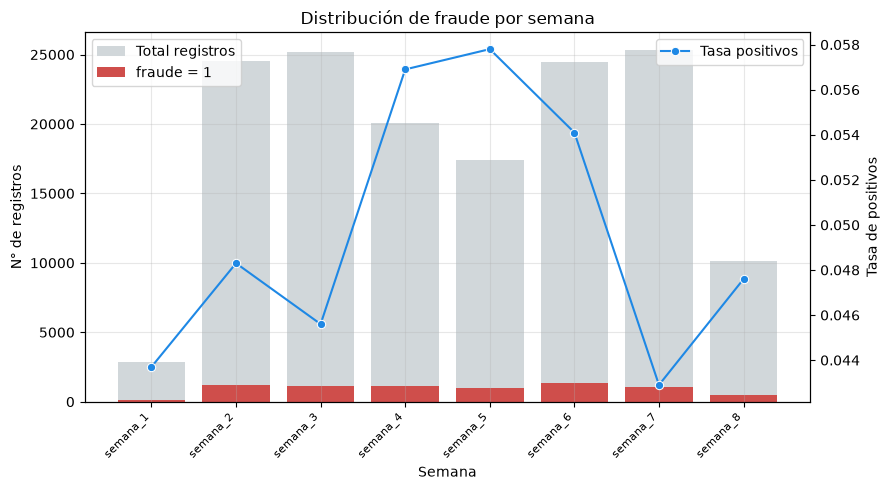

In [11]:
eda.plot_target_by_period(
    weekly,
    output_path=FIGURES_DIR / "distribucion_semanal_target.png",
    target_name=TARGET_COL,
    freq="W",
    close=False,
)
plt.show()

### 4.3 Mes a mes

In [12]:
monthly = eda.target_monthly_distribution(TARGET_COL)
monthly.to_csv(TABLES_DIR / "04c_distribucion_mensual_target.csv", index=False)
monthly

,periodo,n_total,n_positivos,n_negativos,tasa_positivos
0,2020-03,76961,3877,73084,0.0504
1,2020-04,73039,3623,69416,0.0496


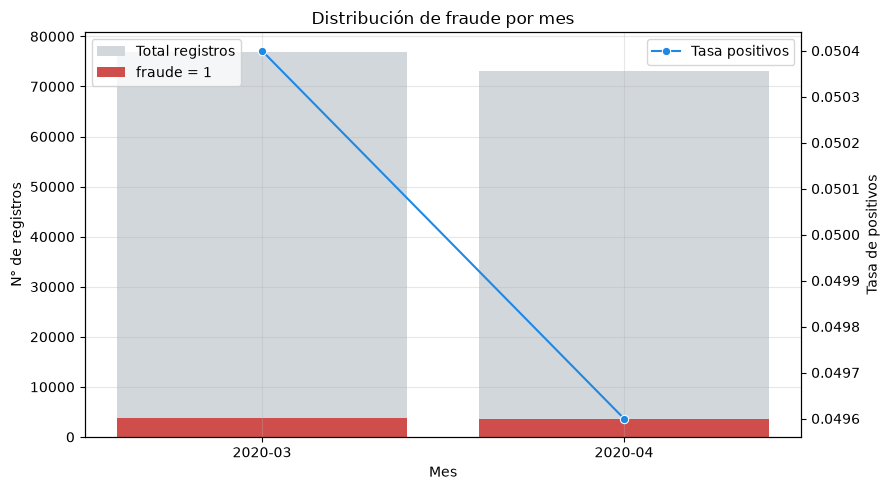

In [13]:
eda.plot_target_by_period(
    monthly,
    output_path=FIGURES_DIR / "distribucion_mensual_target.png",
    target_name=TARGET_COL,
    freq="M",
    close=False,
)
plt.show()

### 4.4 Evolución diaria del fraude en `monto`

Además del conteo de transacciones, interesa ver cómo evoluciona día a día el **monto** involucrado en fraude respecto al monto total transado, ya que una misma tasa de fraude (en cantidad de transacciones) puede representar un impacto económico muy distinto según el monto promedio de esas transacciones.

In [14]:
daily_monto = (
    df.groupby([df["fecha"].dt.date, TARGET_COL])["monto"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={0: "monto_no_fraude", 1: "monto_fraude"})
    .reset_index()
    .rename(columns={"fecha": "periodo"})
)
daily_monto["monto_total"] = daily_monto["monto_no_fraude"] + daily_monto["monto_fraude"]
daily_monto["pct_monto_fraude"] = daily_monto["monto_fraude"] / daily_monto["monto_total"]

daily_monto.to_csv(TABLES_DIR / "04d_evolucion_monto_fraude_diaria.csv", index=False)
daily_monto

fraude,periodo,monto_no_fraude,monto_fraude,monto_total,pct_monto_fraude
0,2020-03-08,113830.82,9798.05,123628.87,0.079254
1,2020-03-09,190010.34,14666.02,204676.36,0.071655
2,2020-03-10,182384.29,17908.67,200292.96,0.089412
3,2020-03-11,183992.13,20076.90,204069.03,0.098383
4,2020-03-12,163283.66,13874.92,177158.58,0.078319
5,2020-03-13,146861.63,9318.35,156179.98,0.059664
6,2020-03-14,100693.76,8460.48,109154.24,0.077509
7,2020-03-15,107846.06,7360.02,115206.08,0.063886
8,2020-03-16,188117.11,15067.43,203184.54,0.074156
9,2020-03-17,190511.42,15368.78,205880.20,0.074649


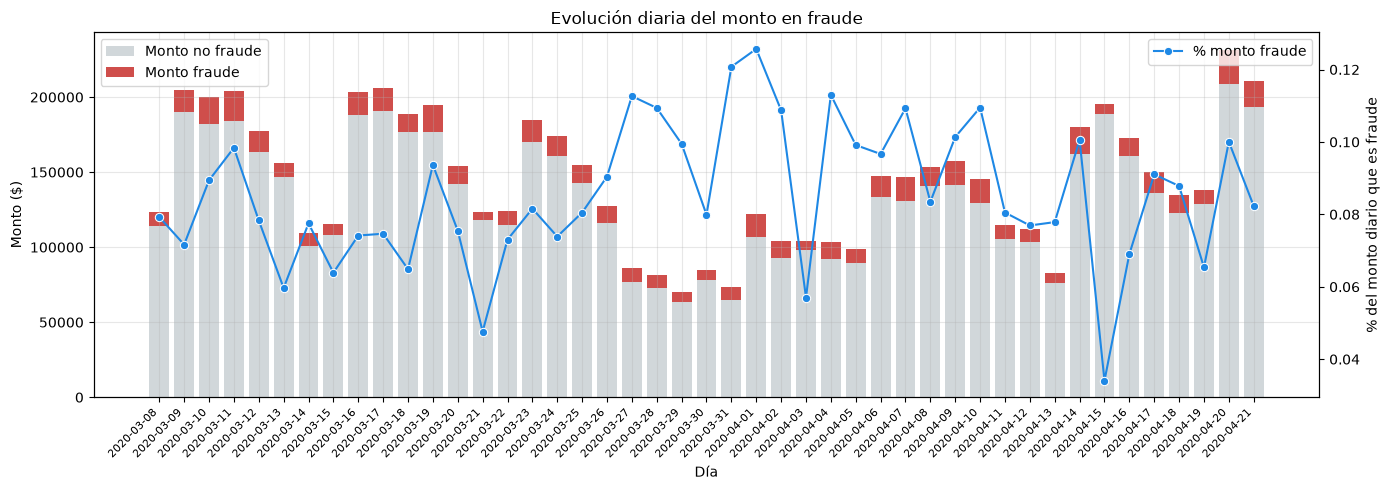

In [15]:
plot_daily_amount_evolution(
    daily_monto,
    output_path=FIGURES_DIR / "evolucion_monto_fraude_diaria.png",
    close=False,
)
plt.show()

**Notas adicionales**
- El porcentaje del monto diario que corresponde a fraude varía entre ~3.4% y ~12.6%, con un promedio cercano al 8.5%, es decir, **más del doble que la tasa de fraude en cantidad de transacciones (~5%)**: las transacciones fraudulentas tienden a tener un monto promedio mayor que las legítimas.
- El pico de participación del monto en fraude se concentra entre el 26 de marzo y el 1 de abril, consistente con el pico de tasa de fraude (en cantidad) observado en la sección 4.1 para ese mismo periodo.

### 4.5 Impacto económico según regla de negocio (25% ganancia / 100% pérdida por fraude no contenido)

**hipótesis general:**

- Se asume que el fraude resgistrado en el dataset es perdida total, es decir se asume que no existe ningún mecanismo de deteccción de fraude, esto con el fin de medir en caso tal, que ganancias y perdidas se han obtenido al no detectar el fraude
- Este interpretación, puede servir de comparativo en caso tal de que se constuya un modelo de ML para detactar fraude, y comprar si al tener un mecansimos de detección de fraude estas ganancias y perdidas pueden verse afectadas de manera positiva, aumentando la ganancia y disminuyendo las pérdidas.

Se construye una tabla que traduce la distribución diaria de fraude a un impacto económico, bajo la regla de negocio:

- Por cada transacción **legítima** (`fraude = 0`) se obtiene una ganancia del **25%** del monto.
- Por cada **fraude confirmado** (`fraude = 1`) se pierde el **100%** del monto, bajo la hipótesis de que el fraude confirmado en el dataset corresponde a fraude que **no se logró contener** (es decir, la transacción se ejecutó y la pérdida fue total, en lugar de una transacción rechazada donde no habría ganancia ni pérdida).

In [16]:
impact = daily_monto[["periodo", "monto_no_fraude", "monto_fraude"]].copy()
impact["ganancia_25pct_legit"] = impact["monto_no_fraude"] * 0.25
impact["perdida_100pct_fraude"] = impact["monto_fraude"] * 1.00
impact["resultado_neto"] = impact["ganancia_25pct_legit"] - impact["perdida_100pct_fraude"]

total_row = impact.drop(columns="periodo").sum()
total_row["periodo"] = "TOTAL"
impact = pd.concat([impact, total_row.to_frame().T], ignore_index=True)

impact.to_csv(TABLES_DIR / "04e_impacto_economico_regla_negocio.csv", index=False)
impact

fraude,periodo,monto_no_fraude,monto_fraude,ganancia_25pct_legit,perdida_100pct_fraude,resultado_neto
0,2020-03-08,113830.82,9798.05,28457.705,9798.05,18659.655
1,2020-03-09,190010.34,14666.02,47502.585,14666.02,32836.565
2,2020-03-10,182384.29,17908.67,45596.0725,17908.67,27687.4025
3,2020-03-11,183992.13,20076.9,45998.0325,20076.9,25921.1325
4,2020-03-12,163283.66,13874.92,40820.915,13874.92,26945.995
5,2020-03-13,146861.63,9318.35,36715.4075,9318.35,27397.0575
6,2020-03-14,100693.76,8460.48,25173.44,8460.48,16712.96
7,2020-03-15,107846.06,7360.02,26961.515,7360.02,19601.495
8,2020-03-16,188117.11,15067.43,47029.2775,15067.43,31961.8475
9,2020-03-17,190511.42,15368.78,47627.855,15368.78,32259.075


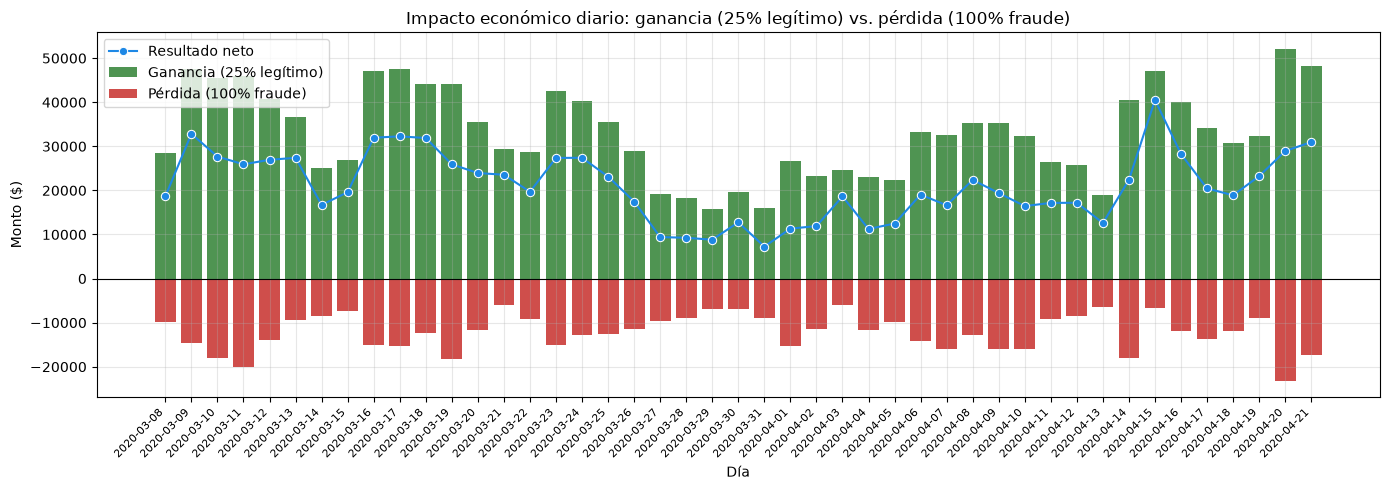

In [17]:
plot_economic_impact(
    impact,
    output_path=FIGURES_DIR / "impacto_economico_diario.png",
    close=False,
)
plt.show()

**Notas adicionales**
- Bajo esta regla, la ganancia total por transacciones legítimas es de ~$1.50M y la pérdida total por fraude no contenido es de ~$0.55M, dejando un **resultado neto positivo de ~$0.95M** en todo el periodo.
- Ningún día individual presenta un resultado neto negativo, aunque los días con mayor `pct_monto_fraude` (fin de marzo) son los que más reducen el margen neto diario.

## 5. Concentración de variables categóricas

Para cada variable categórica (excluyendo `fecha`) se analiza qué tan concentrada está su distribución:

- **top1_pct / top3_pct**: participación de la categoría más frecuente y de las 3 principales.
- **HHI** (índice de Herfindahl-Hirschman, calculado sobre las proporciones de todas las categorías): cercano a **1** indica una sola categoría dominante; cercano a **0** indica una distribución más repartida entre muchas categorías.

In [18]:
cat_conc = eda.categorical_concentration(top_n=10)
cat_conc["summary"].to_csv(TABLES_DIR / "05_concentracion_categoricas_resumen.csv", index=False)
cat_conc["summary"]

,columna,n_categorias,categoria_top1,top1_pct,top3_pct,hhi
0,g,52,BR,0.7442,0.9771,0.5999
1,o,3,(nulo),0.7257,1.0000,0.5654
2,p,2,Y,0.5542,1.0000,0.5059
3,j,8324,cat_43b9c10,0.0155,0.0394,0.0018


--- Columna: g ---


,categoria,n,pct,pct_acumulado
0,BR,111628,0.7442,0.7442
1,AR,31964,0.2131,0.9573
2,UY,2967,0.0198,0.9771
3,US,2273,0.0152,0.9923
4,SE,358,0.0024,0.9947
5,MX,236,0.0016,0.9963
6,(nulo),194,0.0013,0.9976
7,RU,73,0.0005,0.9981
8,ES,69,0.0005,0.9986
9,CO,64,0.0004,0.9990


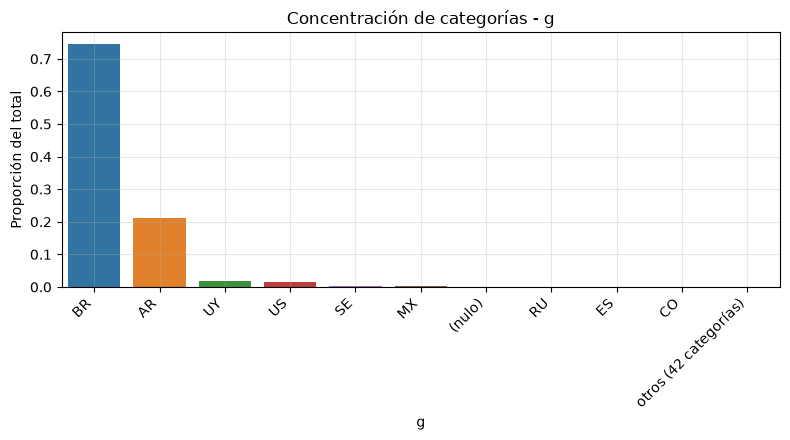

--- Columna: j ---


,categoria,n,pct,pct_acumulado
0,cat_43b9c10,2331,0.0155,0.0155
1,cat_d69bed9,1799,0.0120,0.0275
2,cat_604df77,1784,0.0119,0.0394
3,cat_6c4cfdc,1449,0.0097,0.0491
4,cat_4249bd8,1191,0.0079,0.0570
5,cat_3203c7c,1093,0.0073,0.0643
6,cat_be0af8e,1040,0.0069,0.0712
7,cat_0820fab,938,0.0063,0.0775
8,cat_8ef7164,909,0.0061,0.0836
9,cat_d5975ae,878,0.0059,0.0895


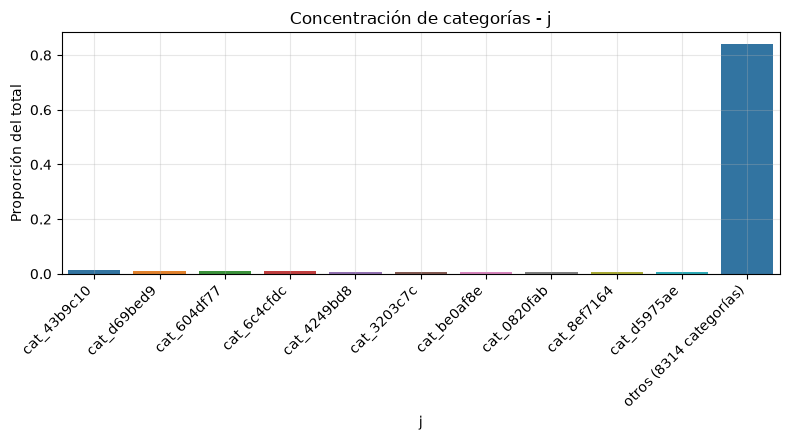

--- Columna: o ---


,categoria,n,pct,pct_acumulado
0,(nulo),108857,0.7257,0.7257
1,Y,24091,0.1606,0.8863
2,N,17052,0.1137,1.0000


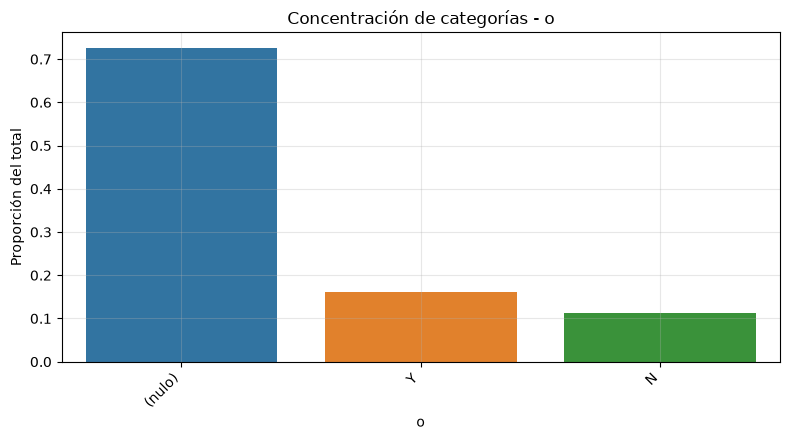

--- Columna: p ---


,categoria,n,pct,pct_acumulado
0,Y,83129,0.5542,0.5542
1,N,66871,0.4458,1.0000


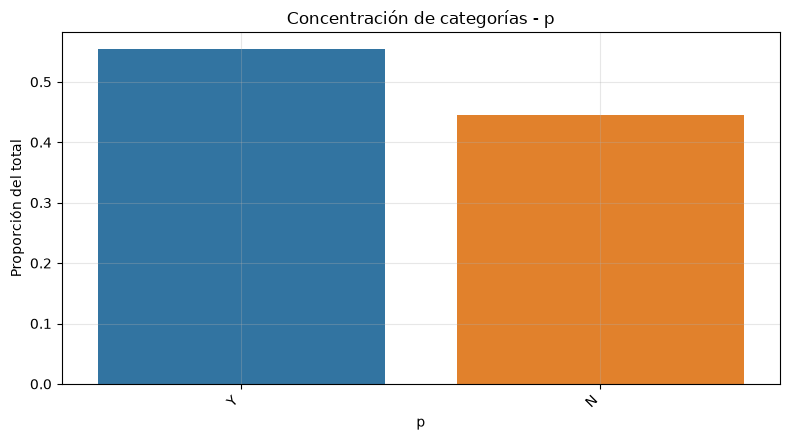

In [19]:
for col, table in cat_conc["tables"].items():
    print(f"--- Columna: {col} ---")
    display(table)
    table.to_csv(TABLES_DIR / f"05_concentracion_{col}.csv", index=False)
    eda.plot_categorical_concentration(
        col, table,
        output_path=FIGURES_DIR / f"concentracion_{col}.png",
        close=False,
    )
    plt.show()

# Conclusiones finales generales

- El dataset tiene 150 mil registros y 19 columnas
- El rango de fechas va desade el 2020-03-08 al 2020-04-21, 44 dias en total 
- ID unico, variable `k`
- El targetr `fraude` tiene aproximadamente un ~5% de fraude confirmado, esto en general se mantiene dia a dia, el 95% restante corresponde a la clase negativa o transacciones que no son fraudulentas
- Cantidad de fraude total 7500 casos
- Las variables categóricas muestran distinto grado de concentración: revisar la sección 5 donde se detalla esto